## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    average_precision_score, roc_auc_score,
    ConfusionMatrixDisplay, PrecisionRecallDisplay
)

import lightgbm as lgb
import xgboost as xgb
import optuna
import shap
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')

%matplotlib inline

RANDOM_STATE = 42
N_FOLDS = 5
np.random.seed(RANDOM_STATE)

---
## 2. Load Data

In [2]:
df = pd.read_csv(Path('../../data/claims_cleaned.csv'))
print(f'Loaded: {df.shape}')
print(f'Target: {df["target"].value_counts().to_dict()}')

Loaded: (2880, 67)
Target: {1: 2427, 0: 453}


---
## 3. Text Embedding — The Key Improvement

In Attempt #1 we only used surface stats (word count, length) from `issueDesc`. Now we embed the full text using a multilingual sentence transformer to capture **semantic meaning**.

Model: `paraphrase-multilingual-MiniLM-L12-v2`
- Handles Swedish, Dutch, Finnish, English
- 384-dim output → PCA to 20 dims (to avoid overfitting on 2,880 rows)

In [3]:
from sentence_transformers import SentenceTransformer

# Combine issueDesc + other column (recovered from raw data)
df_raw = pd.read_excel(Path('../../claim_use_case_dataset.xlsx'), engine='openpyxl')
other_text = df_raw['other'].fillna('').astype(str)
issue_text = df['issueDesc'].fillna('').astype(str)

# Concatenate: issueDesc + other (where available)
combined_text = issue_text + ' ' + other_text
combined_text = combined_text.str.strip()

print(f'Sample combined text (first 200 chars):')
print(f'  [0] {combined_text.iloc[0][:200]}')
print(f'\n  Non-empty other: {(other_text != "").sum()} / {len(other_text)}')

Sample combined text (first 200 chars):
  [0] ***** gÃ¥ngen *** **** mobilen var nÃ¤r *** var pÃ¥ toaletten kl ***** nÃ¥gongÃ¥ng. Efter ***** *** *** varit runt ******** ungdomar. ****** med ungefÃ¤r 50 st bÃ¥de sittande och stÃ¥ende *** under ti

  Non-empty other: 645 / 2880


In [4]:
# Generate embeddings
print('Loading sentence transformer model...')
st_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f'Encoding {len(combined_text)} texts...')
embeddings = st_model.encode(
    combined_text.tolist(),
    show_progress_bar=True,
    batch_size=64
)
print(f'Raw embeddings shape: {embeddings.shape}')

Loading sentence transformer model...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 2880 texts...


Batches:   0%|          | 0/45 [00:00<?, ?it/s]

Raw embeddings shape: (2880, 384)


PCA: 384 -> 20 dimensions
Cumulative explained variance: 0.648


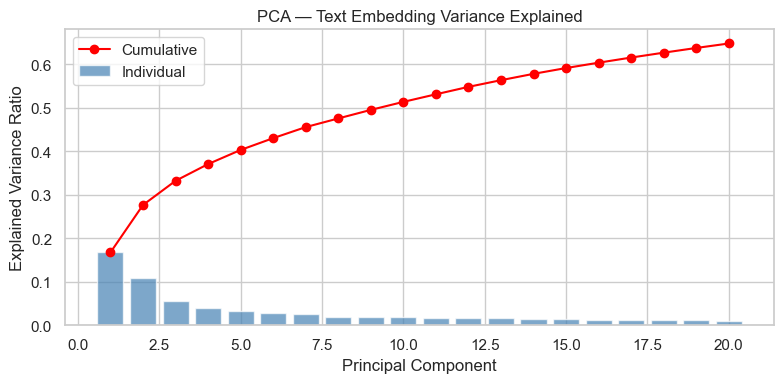

In [5]:
# PCA: 384 dims -> 20 dims
N_COMPONENTS = 20

pca = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
embeddings_pca = pca.fit_transform(embeddings)

explained_var = pca.explained_variance_ratio_.cumsum()
print(f'PCA: {embeddings.shape[1]} -> {N_COMPONENTS} dimensions')
print(f'Cumulative explained variance: {explained_var[-1]:.3f}')

# Plot explained variance
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, N_COMPONENTS+1), pca.explained_variance_ratio_, color='steelblue', alpha=0.7, label='Individual')
ax.plot(range(1, N_COMPONENTS+1), explained_var, 'o-', color='red', label='Cumulative')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Text Embedding Variance Explained')
ax.legend()
plt.tight_layout()
plt.show()

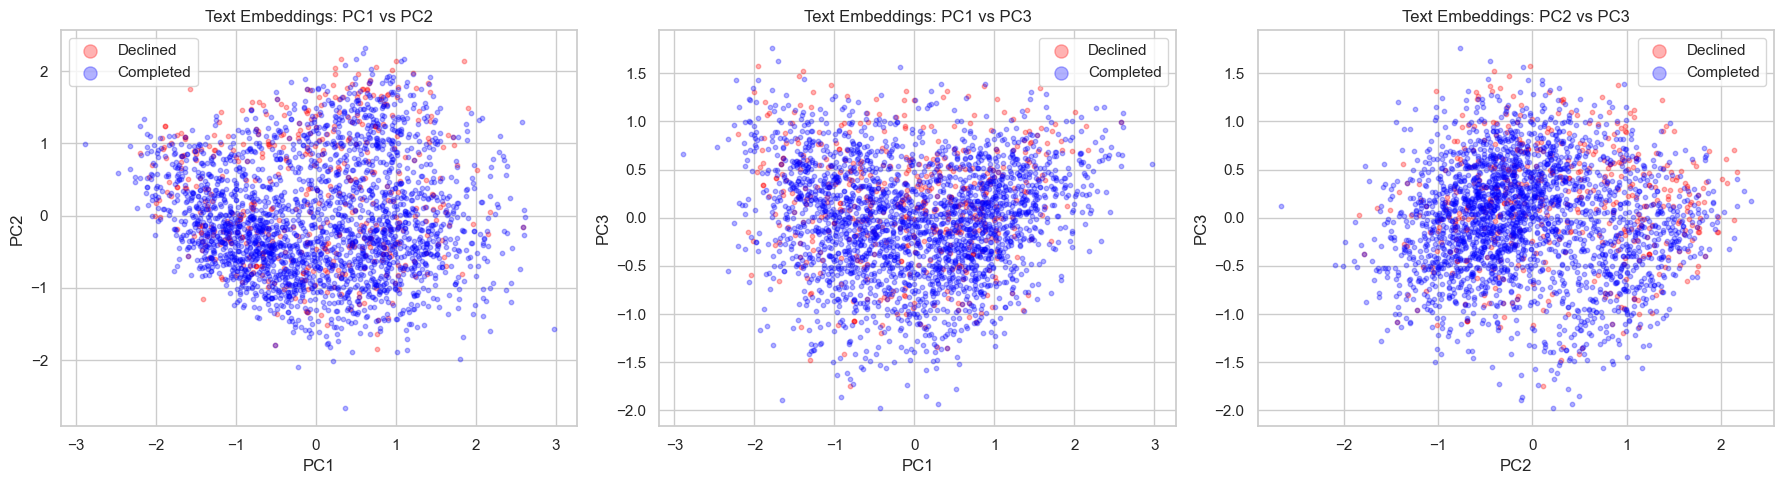

In [6]:
# Check if embeddings separate the classes at all
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (i, j) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    for label, name, color in [(0, 'Declined', 'red'), (1, 'Completed', 'blue')]:
        mask = df['target'].values == label
        ax.scatter(embeddings_pca[mask, i], embeddings_pca[mask, j],
                   alpha=0.3, s=10, label=name, color=color)
    ax.set_xlabel(f'PC{i+1}')
    ax.set_ylabel(f'PC{j+1}')
    ax.legend(markerscale=3)
    ax.set_title(f'Text Embeddings: PC{i+1} vs PC{j+1}')

plt.tight_layout()
plt.show()

---
## 4. Build Feature Matrix

In [7]:
# Same structural features as Attempt #1, minus dead features
DROP_FEATURES = [
    'deviceCost', 'balance_change', 'has_balance_change', 'oldBalanceRRP',
    'balanceRRP', 'smashed', 'frontOrBackCamera', 'other',
    'relationship_encoded', 'buttons', 'connection', 'charging',
]

with open(Path('../../data/feature_columns.txt'), 'r') as f:
    all_features = [line.strip() for line in f.readlines()]

structural_features = [f for f in all_features if f not in DROP_FEATURES]

# Add embedding features
emb_feature_names = [f'text_emb_{i}' for i in range(N_COMPONENTS)]
for i, name in enumerate(emb_feature_names):
    df[name] = embeddings_pca[:, i]

feature_cols = structural_features + emb_feature_names

print(f'Structural features: {len(structural_features)}')
print(f'Embedding features:  {len(emb_feature_names)}')
print(f'Total features:      {len(feature_cols)}')

Structural features: 33
Embedding features:  20
Total features:      53


In [8]:
X = df[feature_cols].fillna(0).values
y = df['target'].values

print(f'X shape: {X.shape}')
print(f'y distribution: {np.bincount(y)} (0=Declined, 1=Completed)')

X shape: (2880, 53)
y distribution: [ 453 2427] (0=Declined, 1=Completed)


---
## 5. Evaluation Helpers (same as Attempt #1, plus extras)

In [9]:
def evaluate_cv(model, X, y, model_name='Model', n_folds=N_FOLDS, use_smote=False):
    """Run stratified K-fold CV with optional SMOTE on training folds."""
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    
    all_y_true, all_y_pred, all_y_proba = [], [], []
    fold_metrics = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        if use_smote:
            smote = SMOTE(random_state=RANDOM_STATE)
            X_train, y_train = smote.fit_resample(X_train, y_train)
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1]
        
        f1_macro = f1_score(y_val, y_pred, average='macro')
        f1_declined = f1_score(y_val, y_pred, pos_label=0)
        pr_auc = average_precision_score(y_val, y_proba)
        roc = roc_auc_score(y_val, y_proba)
        
        fold_metrics.append({
            'fold': fold+1, 'f1_macro': f1_macro, 'f1_declined': f1_declined,
            'pr_auc': pr_auc, 'roc_auc': roc
        })
        
        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)
        all_y_proba.extend(y_proba)
    
    metrics_df = pd.DataFrame(fold_metrics)
    all_y_true = np.array(all_y_true)
    all_y_pred = np.array(all_y_pred)
    all_y_proba = np.array(all_y_proba)
    
    print(f'\n{"="*60}')
    print(f'{model_name} — {n_folds}-Fold CV{" + SMOTE" if use_smote else ""}')
    print(f'{"="*60}')
    print(f'\nPer-fold:')
    print(metrics_df.to_string(index=False))
    print(f'\nMean +/- Std:')
    for col in ['f1_macro', 'f1_declined', 'pr_auc', 'roc_auc']:
        print(f'  {col:15s}: {metrics_df[col].mean():.4f} +/- {metrics_df[col].std():.4f}')
    print(f'\nAggregate Classification Report:')
    print(classification_report(all_y_true, all_y_pred, target_names=['Declined', 'Completed']))
    
    return {
        'metrics_df': metrics_df,
        'y_true': all_y_true, 'y_pred': all_y_pred, 'y_proba': all_y_proba,
    }


def plot_evaluation(results, model_name='Model'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    cm = confusion_matrix(results['y_true'], results['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['Declined', 'Completed']).plot(ax=axes[0], cmap='Blues')
    axes[0].set_title(f'{model_name} — Confusion Matrix')
    
    PrecisionRecallDisplay.from_predictions(
        results['y_true'], results['y_proba'], ax=axes[1], name=model_name
    )
    axes[1].set_title(f'{model_name} — PR Curve')
    
    for label, name in [(0, 'Declined'), (1, 'Completed')]:
        mask = results['y_true'] == label
        axes[2].hist(results['y_proba'][mask], bins=30, alpha=0.5, label=name, density=True)
    axes[2].set_xlabel('P(Completed)')
    axes[2].set_title(f'{model_name} — Probability Distribution')
    axes[2].legend()
    axes[2].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

---
## 6. Model A — Logistic Regression + Embeddings


Logistic Regression + Embeddings — 5-Fold CV

Per-fold:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.581194     0.375427 0.915815 0.713443
    2  0.552448     0.333333 0.897638 0.650492
    3  0.585731     0.398734 0.936334 0.753506
    4  0.553481     0.328671 0.890126 0.642483
    5  0.547334     0.328859 0.913097 0.674000

Mean +/- Std:
  f1_macro       : 0.5640 +/- 0.0180
  f1_declined    : 0.3530 +/- 0.0322
  pr_auc         : 0.9106 +/- 0.0179
  roc_auc        : 0.6868 +/- 0.0464

Aggregate Classification Report:
              precision    recall  f1-score   support

    Declined       0.25      0.58      0.35       453
   Completed       0.90      0.68      0.78      2427

    accuracy                           0.67      2880
   macro avg       0.58      0.63      0.56      2880
weighted avg       0.80      0.67      0.71      2880



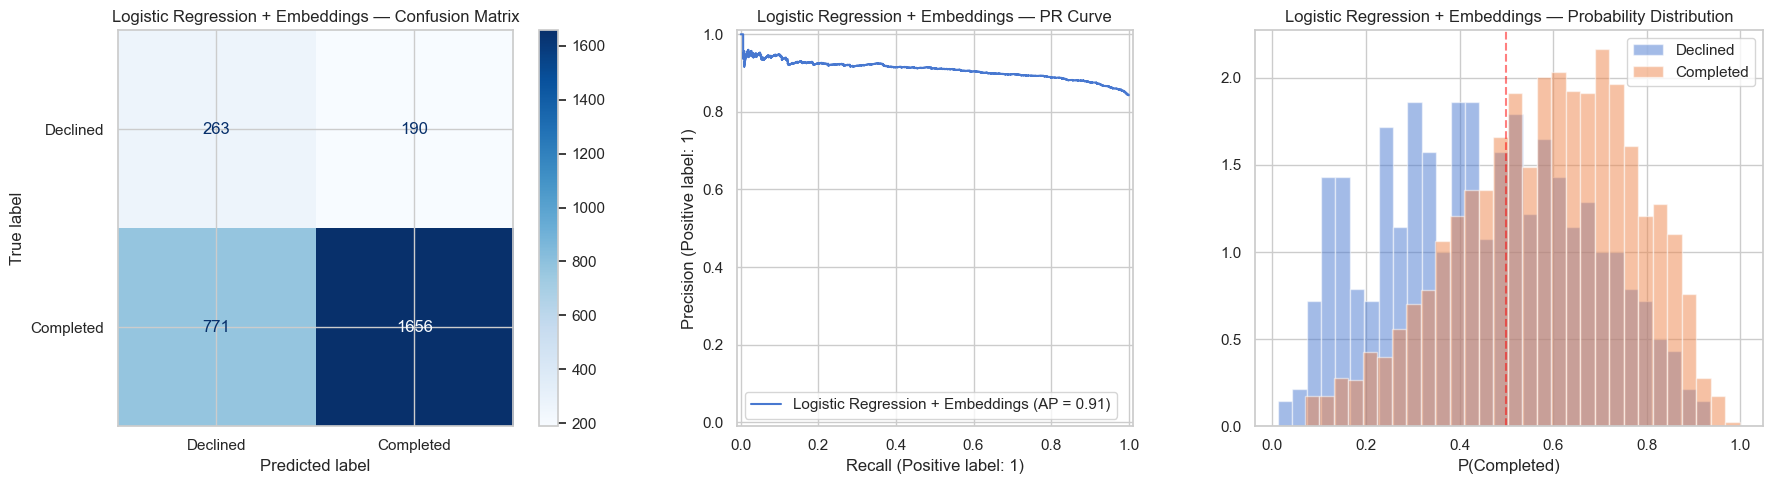

In [10]:
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        class_weight='balanced', max_iter=1000,
        random_state=RANDOM_STATE, solver='lbfgs'
    ))
])

lr_results = evaluate_cv(lr_model, X, y, model_name='Logistic Regression + Embeddings')
plot_evaluation(lr_results, 'Logistic Regression + Embeddings')

---
## 7. Model B — LightGBM + Embeddings (Default)


LightGBM + Embeddings (Default) — 5-Fold CV

Per-fold:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.573656     0.244275 0.903290 0.658116
    2  0.593686     0.289655 0.890068 0.635722
    3  0.614012     0.326531 0.912839 0.703410
    4  0.606496     0.322981 0.893047 0.654129
    5  0.589236     0.287582 0.904439 0.669083

Mean +/- Std:
  f1_macro       : 0.5954 +/- 0.0157
  f1_declined    : 0.2942 +/- 0.0333
  pr_auc         : 0.9007 +/- 0.0092
  roc_auc        : 0.6641 +/- 0.0251

Aggregate Classification Report:
              precision    recall  f1-score   support

    Declined       0.38      0.24      0.30       453
   Completed       0.87      0.93      0.90      2427

    accuracy                           0.82      2880
   macro avg       0.63      0.58      0.60      2880
weighted avg       0.79      0.82      0.80      2880



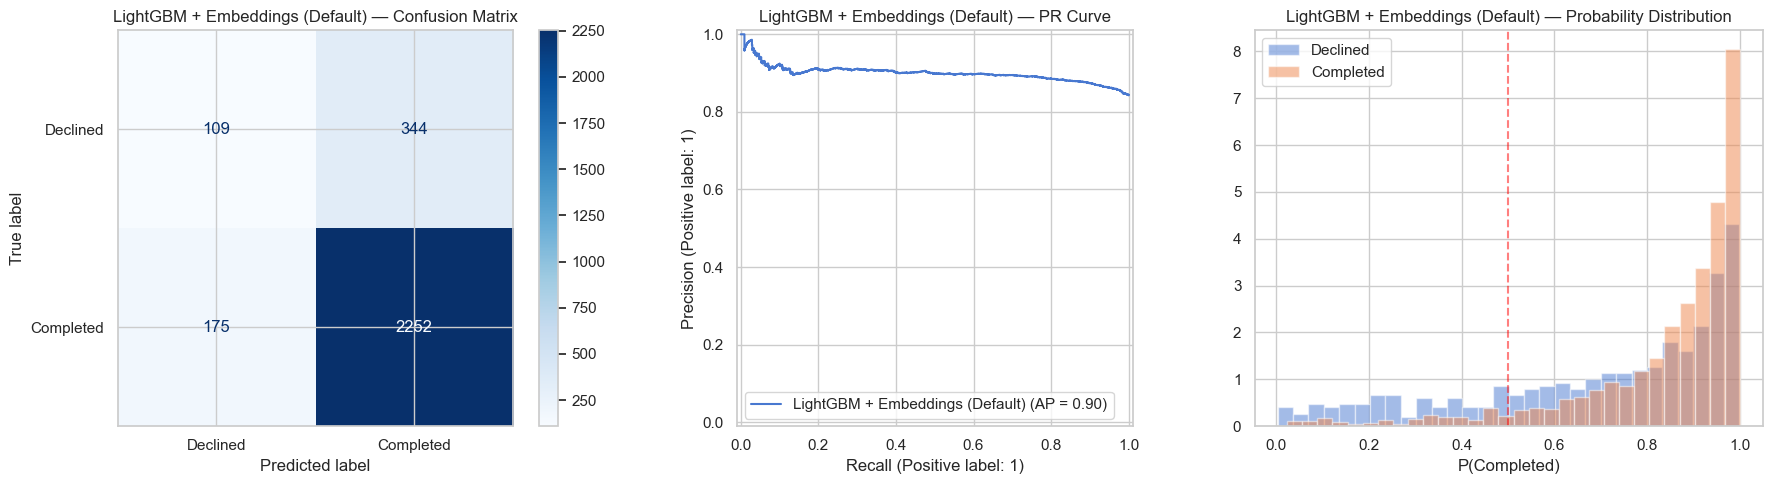

In [11]:
lgb_default = lgb.LGBMClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    is_unbalance=True, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

lgb_default_results = evaluate_cv(lgb_default, X, y, model_name='LightGBM + Embeddings (Default)')
plot_evaluation(lgb_default_results, 'LightGBM + Embeddings (Default)')

---
## 8. Model C — LightGBM + Embeddings + SMOTE


LightGBM + Embeddings + SMOTE — 5-Fold CV + SMOTE

Per-fold:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.581395     0.250000 0.899879 0.661317
    2  0.557173     0.209677 0.881124 0.623971
    3  0.576621     0.248062 0.918659 0.712858
    4  0.593686     0.289655 0.900896 0.679144
    5  0.587302     0.277778 0.909497 0.681636

Mean +/- Std:
  f1_macro       : 0.5792 +/- 0.0139
  f1_declined    : 0.2550 +/- 0.0310
  pr_auc         : 0.9020 +/- 0.0139
  roc_auc        : 0.6718 +/- 0.0325

Aggregate Classification Report:
              precision    recall  f1-score   support

    Declined       0.41      0.19      0.26       453
   Completed       0.86      0.95      0.90      2427

    accuracy                           0.83      2880
   macro avg       0.63      0.57      0.58      2880
weighted avg       0.79      0.83      0.80      2880



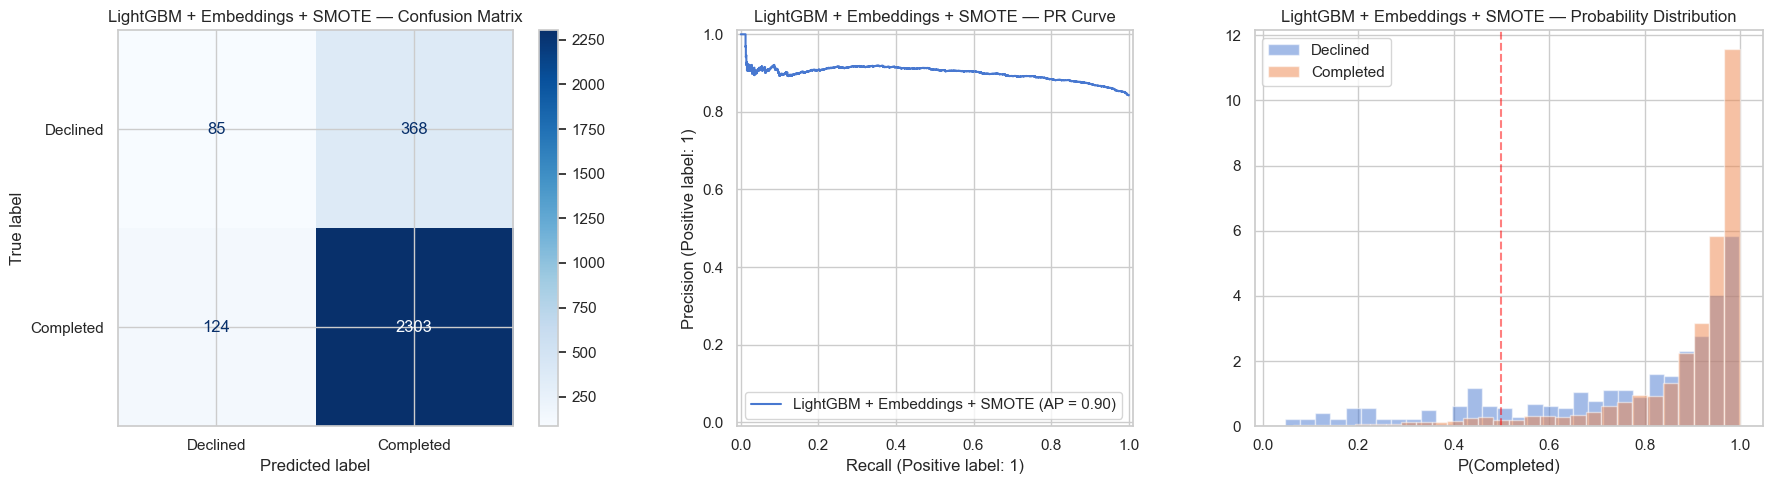

In [12]:
lgb_smote = lgb.LGBMClassifier(
    n_estimators=500, max_depth=5, learning_rate=0.05,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

lgb_smote_results = evaluate_cv(lgb_smote, X, y, model_name='LightGBM + Embeddings + SMOTE', use_smote=True)
plot_evaluation(lgb_smote_results, 'LightGBM + Embeddings + SMOTE')

---
## 9. Model D — LightGBM + Optuna (Fixed Objective)

**Key change:** Objective is `0.5 * f1_macro + 0.5 * f1_declined` so the optimizer can't sacrifice Declined performance.

In [13]:
def lgb_objective_v2(trial):
    """Fixed objective: balanced between F1 macro and F1 declined."""
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 5.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'random_state': RANDOM_STATE,
        'n_jobs': -1,
        'verbose': -1,
    }
    
    model = lgb.LGBMClassifier(**params)
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        X_train, X_val = X[train_idx], X[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        f1_m = f1_score(y_val, y_pred, average='macro')
        f1_d = f1_score(y_val, y_pred, pos_label=0)
        # Balanced objective: reward both overall and declined performance
        scores.append(0.5 * f1_m + 0.5 * f1_d)
    
    return np.mean(scores)

In [14]:
study = optuna.create_study(direction='maximize', study_name='lgb_v2_balanced')
study.optimize(lgb_objective_v2, n_trials=80, show_progress_bar=True)

print(f'\nBest trial:')
print(f'  Score (0.5*F1macro + 0.5*F1declined): {study.best_value:.4f}')
print(f'  Params:')
for k, v in study.best_params.items():
    print(f'    {k}: {v}')

  0%|          | 0/80 [00:00<?, ?it/s]


Best trial:
  Score (0.5*F1macro + 0.5*F1declined): 0.4232
  Params:
    n_estimators: 700
    max_depth: 3
    learning_rate: 0.22736112937235473
    num_leaves: 15
    min_child_samples: 92
    scale_pos_weight: 1.043526193271531
    reg_alpha: 0.05321886027737471
    reg_lambda: 0.0020109934376433777
    subsample: 0.8040837812223004
    colsample_bytree: 0.9829865750179074


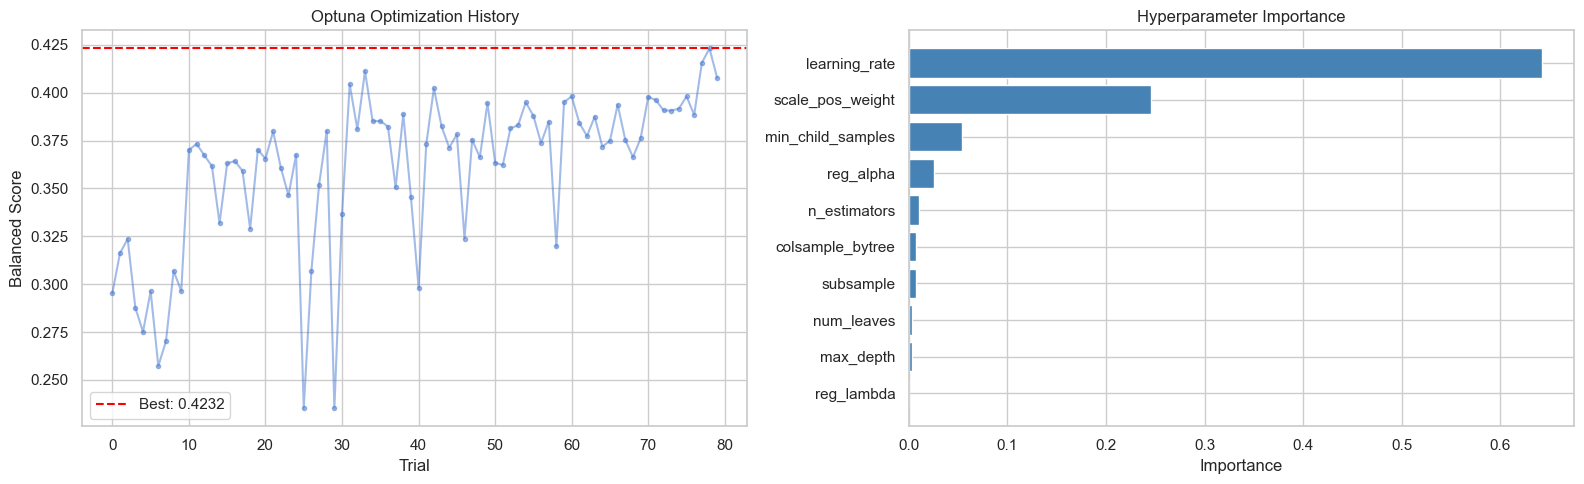

In [15]:
# Optuna visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

values = [t.value for t in study.trials if t.value is not None]
axes[0].plot(values, 'o-', alpha=0.5, markersize=3)
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Balanced Score')
axes[0].set_title('Optuna Optimization History')
axes[0].legend()

try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = sorted(importances.items(), key=lambda x: x[1])
    axes[1].barh([p[0] for p in params_sorted], [p[1] for p in params_sorted], color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
except:
    axes[1].text(0.5, 0.5, 'Could not compute', ha='center', va='center')

plt.tight_layout()
plt.show()


LightGBM + Emb (Tuned v2) — 5-Fold CV

Per-fold:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.580749     0.257576 0.890364 0.636786
    2  0.557790     0.215385 0.892535 0.630853
    3  0.584661     0.266667 0.910851 0.694234
    4  0.589918     0.277372 0.895438 0.654243
    5  0.601581     0.300000 0.917373 0.696046

Mean +/- Std:
  f1_macro       : 0.5829 +/- 0.0161
  f1_declined    : 0.2634 +/- 0.0312
  pr_auc         : 0.9013 +/- 0.0120
  roc_auc        : 0.6624 +/- 0.0311

Aggregate Classification Report:
              precision    recall  f1-score   support

    Declined       0.40      0.20      0.26       453
   Completed       0.86      0.95      0.90      2427

    accuracy                           0.83      2880
   macro avg       0.63      0.57      0.58      2880
weighted avg       0.79      0.83      0.80      2880



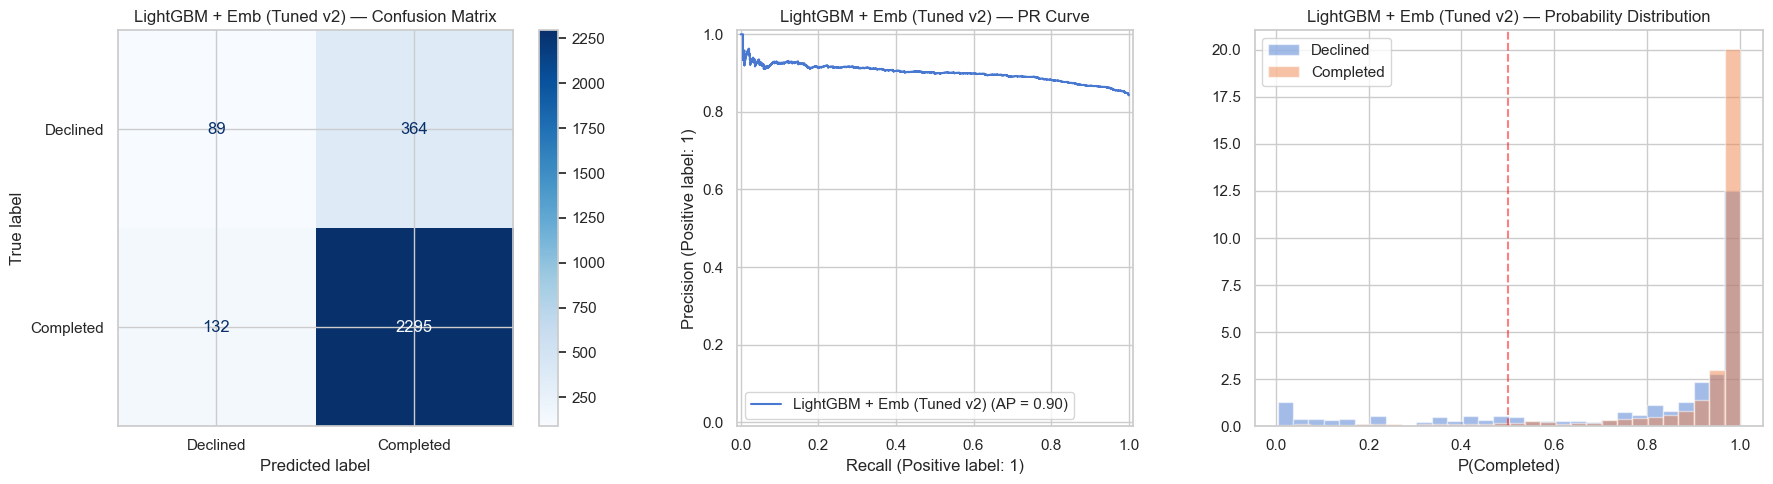

In [16]:
lgb_tuned = lgb.LGBMClassifier(
    **study.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)

lgb_tuned_results = evaluate_cv(lgb_tuned, X, y, model_name='LightGBM + Emb (Tuned v2)')
plot_evaluation(lgb_tuned_results, 'LightGBM + Emb (Tuned v2)')

---
## 10. Model E — XGBoost + Embeddings


XGBoost + Embeddings — 5-Fold CV

Per-fold:
 fold  f1_macro  f1_declined   pr_auc  roc_auc
    1  0.555801     0.208000 0.901740 0.662803
    2  0.559955     0.213115 0.879776 0.618496
    3  0.584285     0.258065 0.918520 0.718772
    4  0.591478     0.279412 0.906695 0.670670
    5  0.601144     0.292308 0.916182 0.699162

Mean +/- Std:
  f1_macro       : 0.5785 +/- 0.0198
  f1_declined    : 0.2502 +/- 0.0382
  pr_auc         : 0.9046 +/- 0.0155
  roc_auc        : 0.6740 +/- 0.0383

Aggregate Classification Report:
              precision    recall  f1-score   support

    Declined       0.43      0.18      0.25       453
   Completed       0.86      0.96      0.91      2427

    accuracy                           0.83      2880
   macro avg       0.65      0.57      0.58      2880
weighted avg       0.79      0.83      0.80      2880



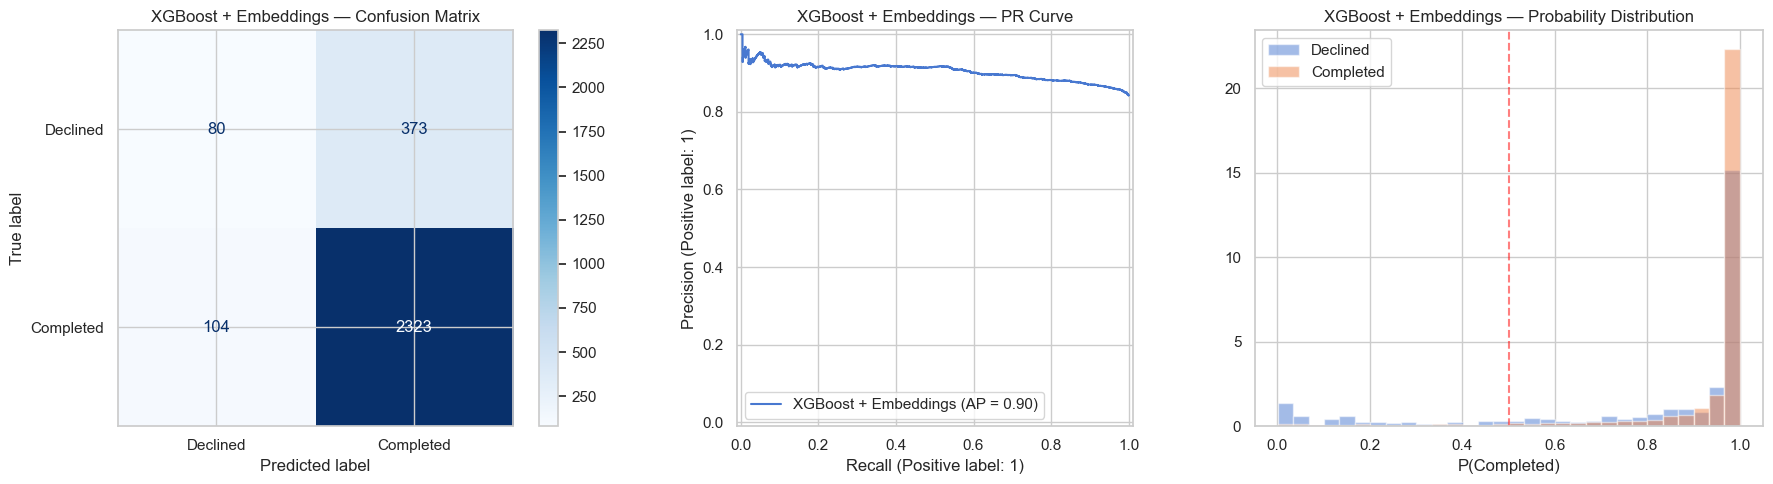

In [17]:
xgb_model = xgb.XGBClassifier(
    n_estimators=study.best_params.get('n_estimators', 500),
    max_depth=study.best_params.get('max_depth', 5),
    learning_rate=study.best_params.get('learning_rate', 0.05),
    scale_pos_weight=study.best_params.get('scale_pos_weight', 5.0),
    reg_alpha=study.best_params.get('reg_alpha', 0.1),
    reg_lambda=study.best_params.get('reg_lambda', 1.0),
    subsample=study.best_params.get('subsample', 0.8),
    colsample_bytree=study.best_params.get('colsample_bytree', 0.8),
    random_state=RANDOM_STATE, n_jobs=-1, eval_metric='logloss', verbosity=0,
)

xgb_results = evaluate_cv(xgb_model, X, y, model_name='XGBoost + Embeddings')
plot_evaluation(xgb_results, 'XGBoost + Embeddings')

---
## 11. Full Model Comparison (Attempt #1 vs Attempt #2)

In [18]:
# Load Attempt #1 comparison for reference
v1_comparison = pd.read_csv(Path('../../models/model_comparison.csv'), index_col=0)
v1_comparison.index = [f'v1: {n}' for n in v1_comparison.index]

# Attempt #2 results
v2_results = {
    'v2: LR + Emb': lr_results,
    'v2: LGB + Emb (Default)': lgb_default_results,
    'v2: LGB + Emb + SMOTE': lgb_smote_results,
    'v2: LGB + Emb (Tuned v2)': lgb_tuned_results,
    'v2: XGB + Emb': xgb_results,
}

v2_comparison = []
for name, res in v2_results.items():
    mdf = res['metrics_df']
    v2_comparison.append({
        'Model': name,
        'F1 Macro (mean)': mdf['f1_macro'].mean(),
        'F1 Macro (std)': mdf['f1_macro'].std(),
        'F1 Declined (mean)': mdf['f1_declined'].mean(),
        'PR-AUC (mean)': mdf['pr_auc'].mean(),
        'ROC-AUC (mean)': mdf['roc_auc'].mean(),
    })

v2_df = pd.DataFrame(v2_comparison).set_index('Model').round(4)

# Combined
combined = pd.concat([v1_comparison, v2_df])
print('=== Full Model Comparison (v1 vs v2) ===')
print(combined.to_string())

=== Full Model Comparison (v1 vs v2) ===
                          F1 Macro (mean)  F1 Macro (std)  F1 Declined (mean)  PR-AUC (mean)  ROC-AUC (mean)
v1: Logistic Regression            0.5188          0.0191              0.3033         0.8942          0.6241
v1: LightGBM (Default)             0.5657          0.0304              0.2800         0.8837          0.6216
v1: LightGBM (Tuned)               0.5526          0.0520              0.2102         0.8811          0.6113
v1: XGBoost                        0.5531          0.0201              0.2053         0.8896          0.6265
v2: LR + Emb                       0.5640          0.0180              0.3530         0.9106          0.6868
v2: LGB + Emb (Default)            0.5954          0.0157              0.2942         0.9007          0.6641
v2: LGB + Emb + SMOTE              0.5792          0.0139              0.2550         0.9020          0.6718
v2: LGB + Emb (Tuned v2)           0.5829          0.0161              0.2634         0

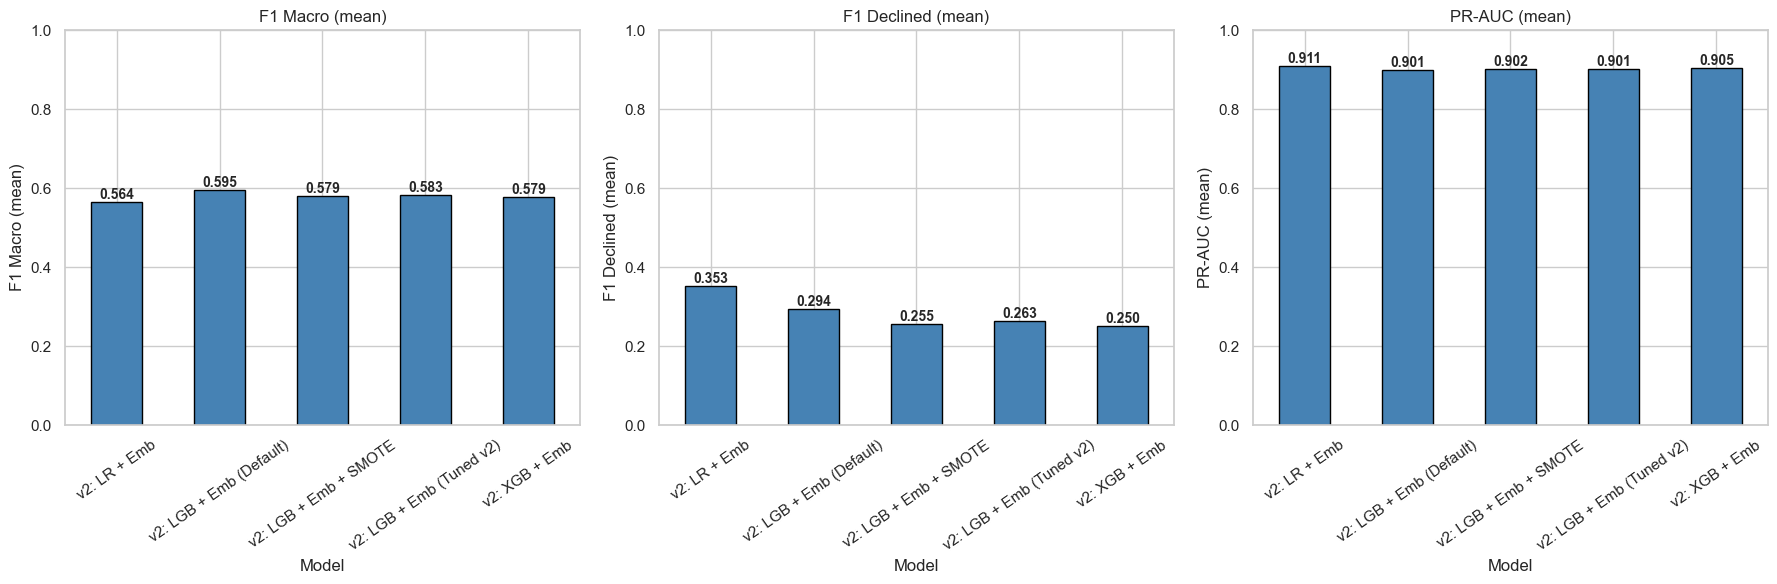

In [19]:
# Visual comparison — v2 models only
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric in zip(axes, ['F1 Macro (mean)', 'F1 Declined (mean)', 'PR-AUC (mean)']):
    v2_df[metric].plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.tick_params(axis='x', rotation=35)
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# Pick the best v2 model
best_v2_name = v2_df['F1 Macro (mean)'].idxmax()
print(f'Best v2 model: {best_v2_name}')
print(v2_df.loc[best_v2_name])

# Improvement over best v1
best_v1_f1 = v1_comparison['F1 Macro (mean)'].max()
best_v2_f1 = v2_df['F1 Macro (mean)'].max()
print(f'\nF1 Macro improvement: {best_v1_f1:.4f} -> {best_v2_f1:.4f} ({(best_v2_f1 - best_v1_f1)/best_v1_f1:.1%} change)')

Best v2 model: v2: LGB + Emb (Default)
F1 Macro (mean)       0.5954
F1 Macro (std)        0.0157
F1 Declined (mean)    0.2942
PR-AUC (mean)         0.9007
ROC-AUC (mean)        0.6641
Name: v2: LGB + Emb (Default), dtype: float64

F1 Macro improvement: 0.5657 -> 0.5954 (5.3% change)


---
## 12. Threshold Optimization (on Best v2 Model)

In [21]:
# Use the best performing model's CV probabilities
# Determine which results to use
all_v2 = {
    'LR + Emb': lr_results,
    'LGB Default': lgb_default_results,
    'LGB SMOTE': lgb_smote_results,
    'LGB Tuned': lgb_tuned_results,
    'XGB': xgb_results,
}
best_key = max(all_v2, key=lambda k: all_v2[k]['metrics_df']['f1_macro'].mean())
best_results = all_v2[best_key]
print(f'Threshold tuning on: {best_key}')

y_true = best_results['y_true']
y_proba = best_results['y_proba']

thresholds = np.arange(0.1, 0.95, 0.01)
f1_macros = []
f1_declineds = []
recall_declineds = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_macros.append(f1_score(y_true, y_pred_t, average='macro'))
    f1_declineds.append(f1_score(y_true, y_pred_t, pos_label=0))
    # Recall for declined
    declined_mask = y_true == 0
    recall_declineds.append((y_pred_t[declined_mask] == 0).mean())

best_thresh_macro = thresholds[np.argmax(f1_macros)]
best_thresh_declined = thresholds[np.argmax(f1_declineds)]
# Balanced: best threshold where F1 macro > 0.55 AND recall declined > 0.40
balanced_mask = [(fm > 0.55) and (rd > 0.40) for fm, rd in zip(f1_macros, recall_declineds)]
if any(balanced_mask):
    balanced_indices = [i for i, m in enumerate(balanced_mask) if m]
    best_thresh_balanced = thresholds[balanced_indices[np.argmax([f1_macros[i] for i in balanced_indices])]]
else:
    best_thresh_balanced = best_thresh_macro

print(f'Best threshold for F1 Macro:       {best_thresh_macro:.2f} (F1={max(f1_macros):.4f})')
print(f'Best threshold for F1 Declined:    {best_thresh_declined:.2f} (F1={max(f1_declineds):.4f})')
print(f'Best balanced threshold:           {best_thresh_balanced:.2f}')
print(f'Default threshold (0.50):          F1 Macro={f1_score(y_true, (y_proba >= 0.5).astype(int), average="macro"):.4f}')

Threshold tuning on: LGB Default
Best threshold for F1 Macro:       0.61 (F1=0.6141)
Best threshold for F1 Declined:    0.78 (F1=0.3610)
Best balanced threshold:           0.70
Default threshold (0.50):          F1 Macro=0.5962


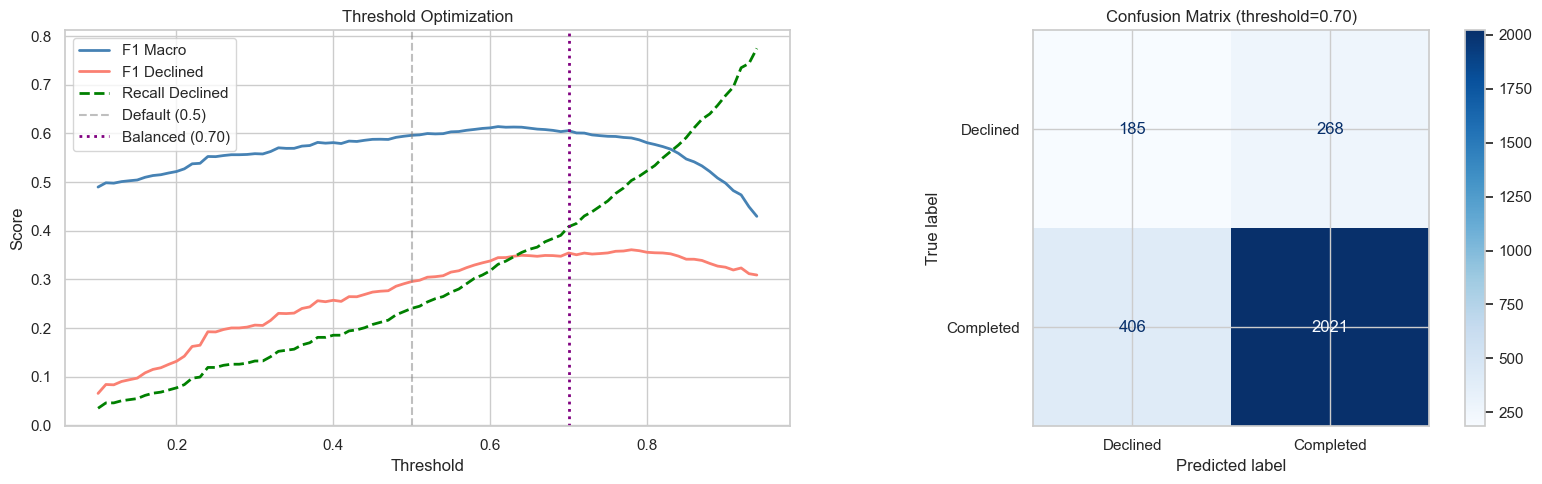

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Threshold curves
axes[0].plot(thresholds, f1_macros, label='F1 Macro', color='steelblue', linewidth=2)
axes[0].plot(thresholds, f1_declineds, label='F1 Declined', color='salmon', linewidth=2)
axes[0].plot(thresholds, recall_declineds, label='Recall Declined', color='green', linewidth=2, linestyle='--')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Default (0.5)')
axes[0].axvline(x=best_thresh_balanced, color='purple', linestyle=':', linewidth=2, label=f'Balanced ({best_thresh_balanced:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Threshold Optimization')
axes[0].legend()

# Confusion matrix with balanced threshold
y_pred_balanced = (y_proba >= best_thresh_balanced).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred_balanced),
    display_labels=['Declined', 'Completed']
).plot(ax=axes[1], cmap='Blues')
axes[1].set_title(f'Confusion Matrix (threshold={best_thresh_balanced:.2f})')

plt.tight_layout()
plt.show()

In [23]:
optimal_threshold = best_thresh_balanced

print(f'=== Final Report with Optimized Threshold ({optimal_threshold:.2f}) ===')
y_pred_final = (y_proba >= optimal_threshold).astype(int)
print(classification_report(y_true, y_pred_final, target_names=['Declined', 'Completed']))

print(f'\n=== Comparison: Default Threshold (0.50) ===')
y_pred_default = (y_proba >= 0.5).astype(int)
print(classification_report(y_true, y_pred_default, target_names=['Declined', 'Completed']))

=== Final Report with Optimized Threshold (0.70) ===
              precision    recall  f1-score   support

    Declined       0.31      0.41      0.35       453
   Completed       0.88      0.83      0.86      2427

    accuracy                           0.77      2880
   macro avg       0.60      0.62      0.61      2880
weighted avg       0.79      0.77      0.78      2880


=== Comparison: Default Threshold (0.50) ===
              precision    recall  f1-score   support

    Declined       0.38      0.24      0.30       453
   Completed       0.87      0.93      0.90      2427

    accuracy                           0.82      2880
   macro avg       0.63      0.58      0.60      2880
weighted avg       0.79      0.82      0.80      2880



---
## 13. SHAP Explainability (Final Model)

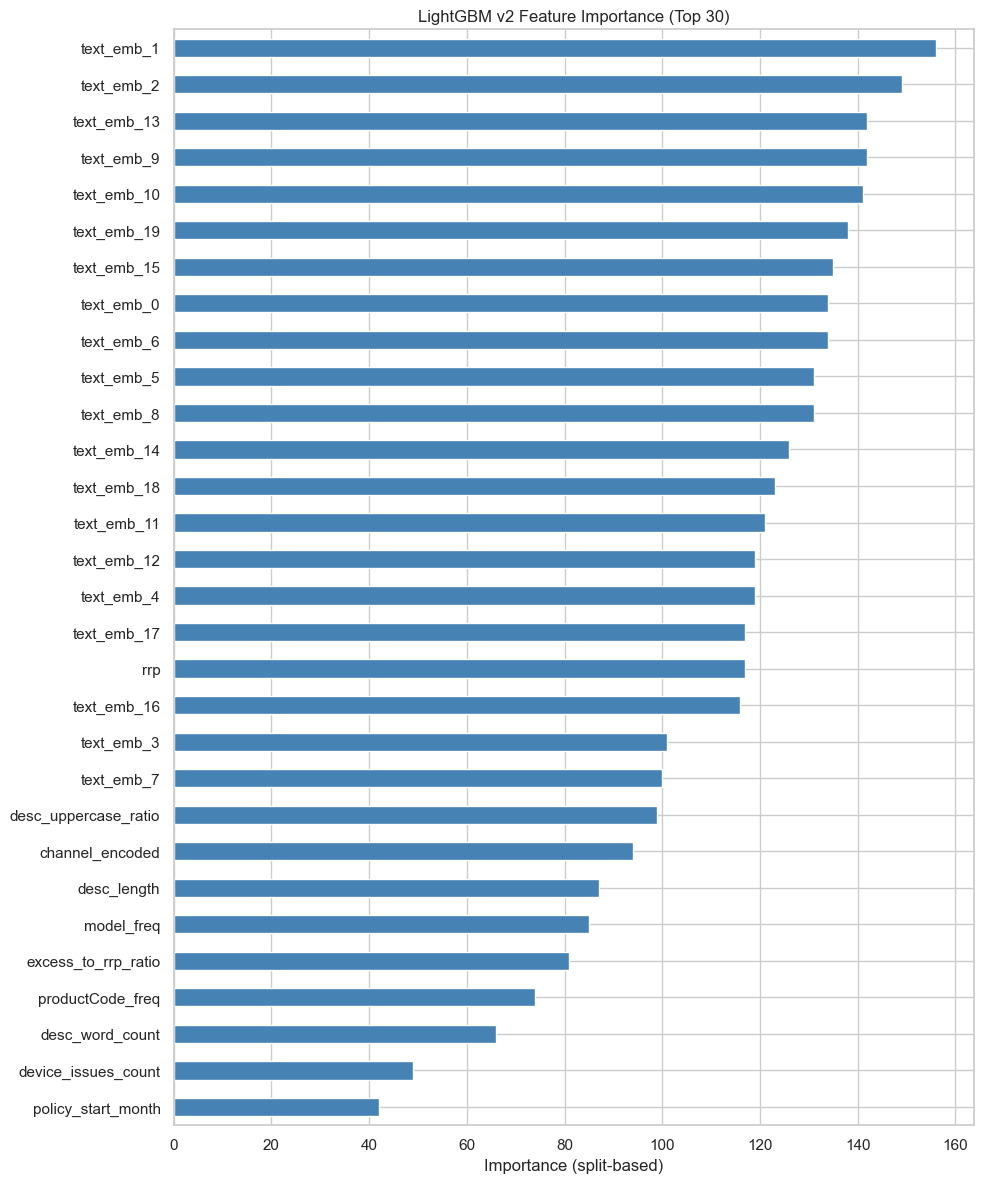

In [24]:
# Train final model on full data
final_model = lgb.LGBMClassifier(
    **study.best_params, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
final_model.fit(X, y)

# Native feature importance
importance = pd.Series(final_model.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 12))
importance.tail(30).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('LightGBM v2 Feature Importance (Top 30)')
ax.set_xlabel('Importance (split-based)')
plt.tight_layout()
plt.show()

In [25]:
# SHAP values
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f'SHAP values shape: {shap_vals.shape}')

SHAP values shape: (2880, 53)


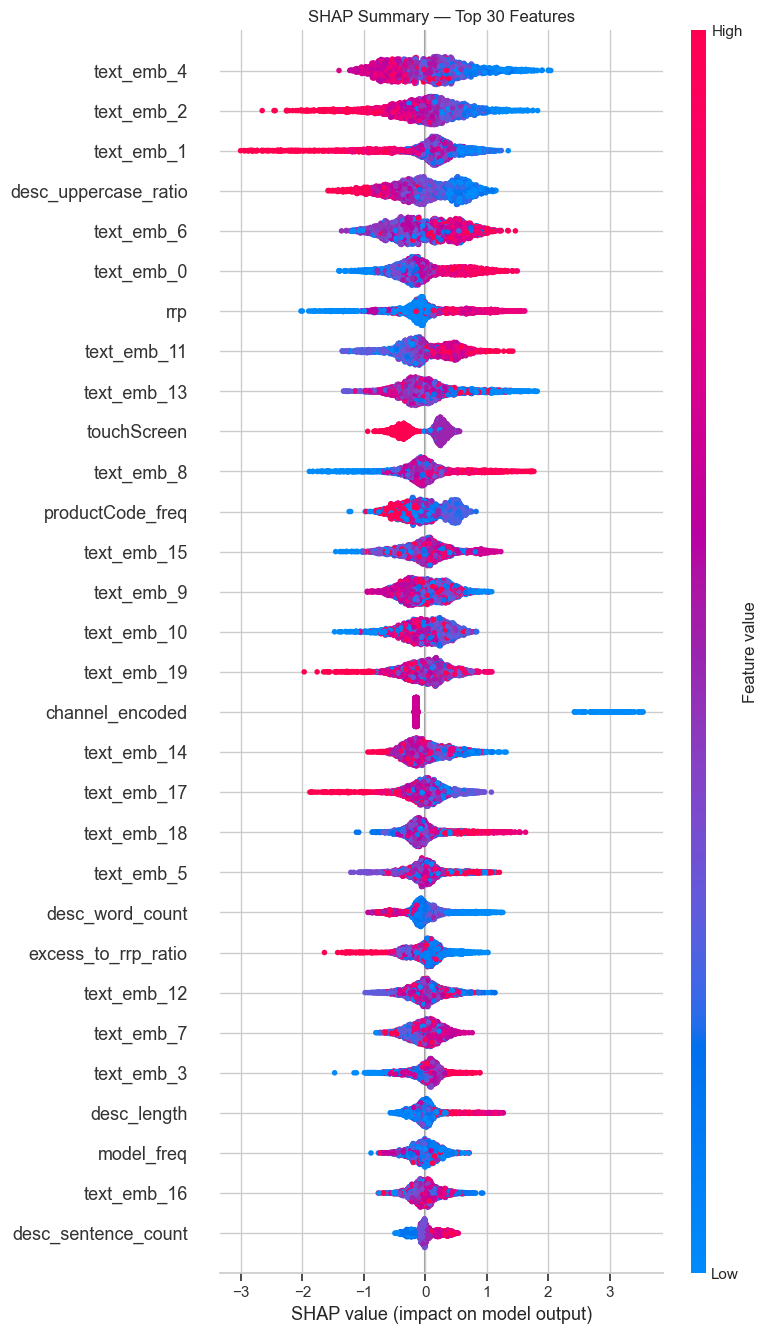

In [26]:
# SHAP summary (beeswarm)
plt.figure(figsize=(12, 12))
shap.summary_plot(shap_vals, X, feature_names=feature_cols, show=False, max_display=30)
plt.title('SHAP Summary — Top 30 Features')
plt.tight_layout()
plt.show()

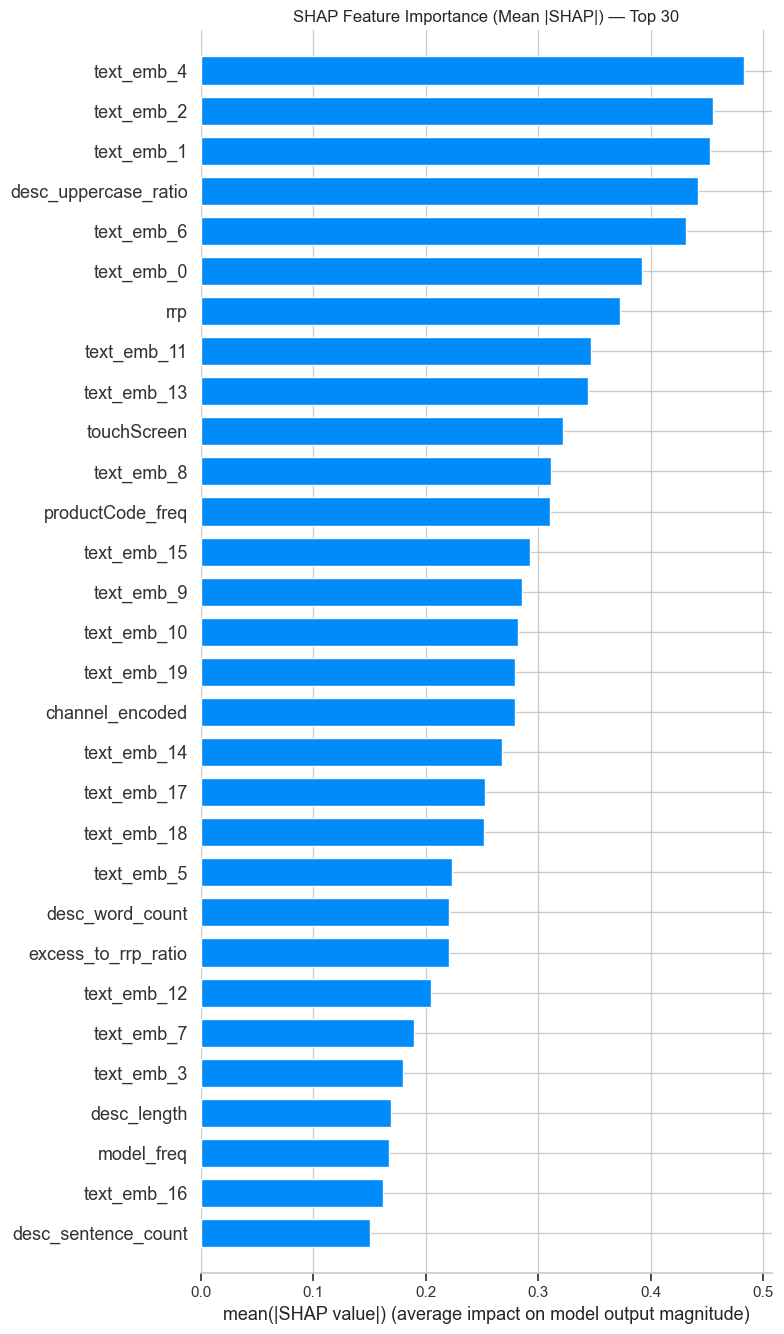

In [27]:
# SHAP bar plot
plt.figure(figsize=(10, 10))
shap.summary_plot(shap_vals, X, feature_names=feature_cols, plot_type='bar', show=False, max_display=30)
plt.title('SHAP Feature Importance (Mean |SHAP|) — Top 30')
plt.tight_layout()
plt.show()

Claim 13: actual=Declined, predicted P(Completed)=0.104


<Figure size 1400x400 with 0 Axes>

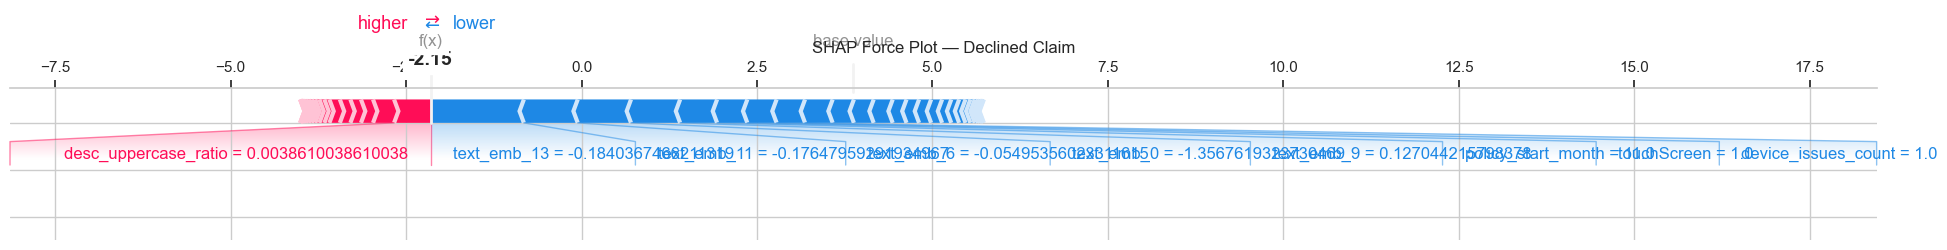

In [28]:
# Explain a declined claim
declined_idx = np.where(y == 0)[0][0]
print(f'Claim {declined_idx}: actual={"Declined"}, predicted P(Completed)={final_model.predict_proba(X[declined_idx:declined_idx+1])[0][1]:.3f}')

plt.figure(figsize=(14, 4))
shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value,
    shap_vals[declined_idx], X[declined_idx],
    feature_names=feature_cols, matplotlib=True, show=False
)
plt.title(f'SHAP Force Plot — Declined Claim')
plt.tight_layout()
plt.show()

In [29]:
# How much do embeddings contribute vs structural features?
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_by_feature = pd.Series(mean_abs_shap, index=feature_cols)

emb_shap = shap_by_feature[emb_feature_names].sum()
struct_shap = shap_by_feature[structural_features].sum()
total_shap = emb_shap + struct_shap

print(f'SHAP contribution breakdown:')
print(f'  Structural features: {struct_shap:.4f} ({struct_shap/total_shap:.1%})')
print(f'  Text embeddings:     {emb_shap:.4f} ({emb_shap/total_shap:.1%})')

SHAP contribution breakdown:
  Structural features: 3.5816 (37.0%)
  Text embeddings:     6.0860 (63.0%)


---
## 14. Save Artifacts

In [30]:
output_dir = Path('../../models')
output_dir.mkdir(exist_ok=True)

# Model
joblib.dump(final_model, output_dir / 'lgb_claim_model_v2.joblib')

# SHAP values
shap_df = pd.DataFrame(shap_vals, columns=feature_cols)
shap_df.to_csv(output_dir / 'shap_values_v2.csv', index=False)

# PCA model (needed to transform new text at inference)
joblib.dump(pca, output_dir / 'text_pca_v2.joblib')

# Config
config = {
    'optimal_threshold': float(optimal_threshold),
    'feature_columns': feature_cols,
    'structural_features': structural_features,
    'embedding_features': emb_feature_names,
    'n_pca_components': N_COMPONENTS,
    'embedding_model': 'paraphrase-multilingual-MiniLM-L12-v2',
    'best_params': study.best_params,
}
with open(output_dir / 'model_config_v2.json', 'w') as f:
    json.dump(config, f, indent=2)

# Full comparison table
combined.to_csv(output_dir / 'model_comparison_v1_v2.csv')

# Embeddings (for reuse in GenAI pipeline)
np.save(output_dir / 'text_embeddings_raw.npy', embeddings)
np.save(output_dir / 'text_embeddings_pca.npy', embeddings_pca)

print('Saved artifacts:')
for f in sorted(output_dir.glob('*v2*')):
    print(f'  {f.name} ({f.stat().st_size / 1024:.0f} KB)')
print(f'  text_embeddings_raw.npy ({(output_dir / "text_embeddings_raw.npy").stat().st_size / 1024:.0f} KB)')
print(f'  text_embeddings_pca.npy ({(output_dir / "text_embeddings_pca.npy").stat().st_size / 1024:.0f} KB)')

Saved artifacts:
  lgb_claim_model_v2.joblib (562 KB)
  model_comparison_v1_v2.csv (1 KB)
  model_comparison_v1_v2_v3.csv (1 KB)
  model_config_v2.json (3 KB)
  shap_values_v2.csv (2730 KB)
  text_pca_v2.joblib (33 KB)
  text_embeddings_raw.npy (4320 KB)
  text_embeddings_pca.npy (225 KB)


---
## Wrap up

Text embeddings helped a bit. F1 macro went from 0.566 to 0.595, and SHAP shows embeddings contribute 63% of feature importance, so the text really does matter.

But we compressed 384 dims down to 20 with PCA and lost 35% of the variance. Also sentence-level embeddings are kind of coarse - they average the whole description into one vector.

SMOTE didn't help (actually made things worse). The default LightGBM with is_unbalance=True keeps beating the tuned version, which is annoying.

Saved everything to `models/`. Going to try deeper NLP next - TF-IDF, LSTM, BERT.